In [6]:
import os
import warnings
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
import src.dataset_generator as dataset_generator
import src.auxiliar as aux
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

SMALL_SIZE = 10+2
MEDIUM_SIZE = 14+2
BIGGER_SIZE = 18+2

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

class_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']
model_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']


# We choose the size big enough to see the scalability of the algorithms, but not too big to avoid too long running times
n_samples = 500

In [ ]:
x = np.arange(0,1,0.0001)
raw_1 = lambda x : 1 - x
raw_2 = lambda x : x
raws = [raw_1, raw_2]
domain = [0,1]
sample_points = [10,25,50,75,100, 500, 1000, 5000, 10000, 50000]

In [13]:
train_scores, test_scores = [], []
for s in tqdm(sample_points):
	train_ss, test_ss = [], []
	for _ in range(100):
		x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
		x_data = x_data.reshape(-1,1)
		clf = RandomForestClassifier(n_estimators=10, max_depth=5)
		clf = make_pipeline(StandardScaler(), clf)
		clf.fit(x_data, y_data)

		score = clf.score(x_data, y_data)
		train_ss.append(score)

		x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
		x_data = x_data.reshape(-1,1)
		score = clf.score(x_data, y_data)
		test_ss.append(score)

	train_scores.append(train_ss)
	test_scores.append(test_ss)

data_path = './data/tree_example'
os.makedirs(data_path, exist_ok=True)
np.save(os.path.join(data_path, 'rfc_train_scores_v2.npy'), train_scores)
np.save(os.path.join(data_path, 'rfc_test_scores_v2.npy'), test_scores)

100%|██████████| 10/10 [01:11<00:00,  7.12s/it]


In [ ]:
train_scores, test_scores = [], []
for s in tqdm(sample_points):
	train_ss, test_ss = [], []
	for _ in range(10):

		with warnings.catch_warnings():
			warnings.filterwarnings("ignore", category=ConvergenceWarning)

			x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
			x_data = x_data.reshape(-1,1)

			clf = MLPClassifier(hidden_layer_sizes=[128,64,32], batch_size=32)
			clf = make_pipeline(StandardScaler(), clf)
			clf.fit(x_data, y_data)

			score = clf.score(x_data, y_data)
			train_ss.append(score)

			x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
			x_data = x_data.reshape(-1,1)
			score = clf.score(x_data, y_data)
			test_ss.append(score)

	train_scores.append(train_ss)
	test_scores.append(test_ss)

data_path = './data/tree_example'
os.makedirs(data_path, exist_ok=True)
np.save(os.path.join(data_path, 'mlp_train_scores.npy'), train_scores)
np.save(os.path.join(data_path, 'mlp_test_scores.npy'), test_scores)

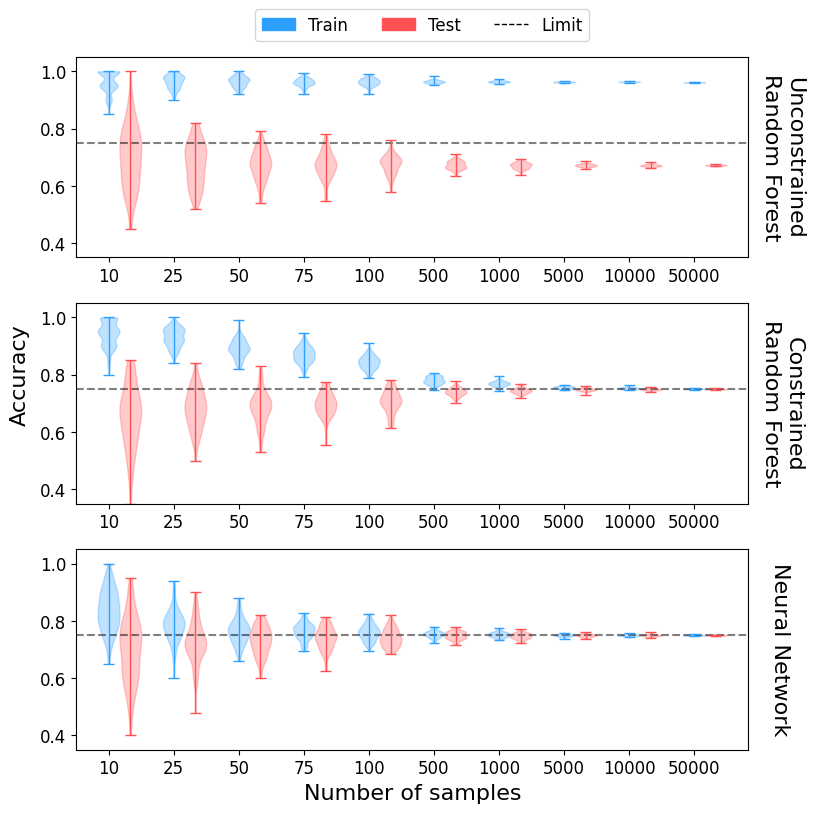

In [29]:
limit = 3/4
data_path = './data/tree_example'
sample_points = np.array([10,25,50,75,100, 500, 1000, 5000, 10000, 50000])

fig, ax = plt.subplots(3,1,figsize=(8,8))

pos = 3*np.arange(len(sample_points))
ax[0].plot([-1.5, 3*len(sample_points)+1.5], [limit, limit], 'k--', alpha=0.5)
ax[1].plot([-1.5, 3*len(sample_points)+1.5], [limit, limit], 'k--', alpha=0.5)
ax[2].plot([-1.5, 3*len(sample_points)+1.5], [limit, limit], 'k--', alpha=0.5)

train_scores = np.load(os.path.join(data_path, 'rfc_train_scores.npy'))
test_scores = np.load(os.path.join(data_path, 'rfc_test_scores.npy'))
parts = ax[0].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[0].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

train_scores = np.load(os.path.join(data_path, 'rfc_train_scores_v2.npy'))
test_scores = np.load(os.path.join(data_path, 'rfc_test_scores_v2.npy'))
parts = ax[1].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[1].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

train_scores = np.load(os.path.join(data_path, 'mlp_train_scores.npy'))
test_scores = np.load(os.path.join(data_path, 'mlp_test_scores.npy'))
parts = ax[2].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[2].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

legend_elements = [Patch(facecolor=model_colors[0], edgecolor=model_colors[0], label='Train'), 
                   Patch(facecolor=model_colors[1], edgecolor=model_colors[1], label='Test'),
                   Line2D([0], [0], color='k', lw=1, linestyle='--', label='Limit')]
fig.legend(handles=legend_elements, ncols=3, bbox_to_anchor=(0.5, 1.025), loc='upper center')

fig.suptitle('')

for i in range(3):
	ax[i].set_xlim(-1.5, 3*len(sample_points)-0.5)
	ax[i].set_ylim(0.35, 1.05)
	ax[i].set_xticks(pos, sample_points)
	#ax[i].legend(handles=legend_elements, ncols=1, loc='lower right')
ax[2].set_xlabel('Number of samples')

label = fig.text(-0.015,0.5,'Accuracy', rotation=90, fontsize=MEDIUM_SIZE)
ax[0].set_ylabel('Unconstrained\nRandom Forest', rotation=270, labelpad=40)
ax[0].yaxis.set_label_position("right")
ax[1].set_ylabel('Constrained\nRandom Forest', rotation=270, labelpad=40)
ax[1].yaxis.set_label_position("right")
ax[2].set_ylabel('Neural Network', rotation=270, labelpad=30)
ax[2].yaxis.set_label_position("right")

plt.tight_layout()
plt.savefig('./images/why_example.png', dpi=300, bbox_inches='tight')
plt.show()